# Theorem 1, built from scratch

This notebook builds the paper's core contribution -- the uniform risk-coverage band --
cell by cell, so you can see exactly how each piece of the theorem statement becomes code,
without any of the surrounding CLI/config machinery `scripts/run_synthetic_validity.py` uses.

Mirrors `scripts/run_synthetic_validity.py` (see `docs/REPRODUCING.md`); use that script for
automated reproduction, this notebook for understanding *why* it works.

In [1]:
import sys
sys.path.insert(0, "..")

import numpy as np
import matplotlib.pyplot as plt

from src.bands import sorted_filtration, uniform_band
from src.bands.validity import is_violated, clopper_pearson_ci_on_rate

rng = np.random.default_rng(20260727)  # the paper's own master seed, Appendix J.1

## Step 1: the sorted filtration

Everything starts with sorting items by a confidence score. We'll use a genuinely
uninformative score here (independent of the loss) -- the *homogeneous world* the paper's
own Theorem 2 (the lower bound) is stated in, and the hardest case for any band to handle
well, since there's no signal to exploit.

In [2]:
n = 20_000
p = 0.15  # true risk, the same in Section 5.2's necessity experiment

losses = rng.binomial(1, p, size=n).astype(float)
scores = rng.normal(size=n)  # independent of loss -> homogeneous world
eta = np.full(n, p)          # exact conditional risk (we're in the "Tier A" setting)

pi = sorted_filtration.build_permutation(scores, rng)
print("First 10 sorted-order indices:", pi[:10])

First 10 sorted-order indices: [12315 11762 13989 15860 12384 15760 18457  4940   189 10279]


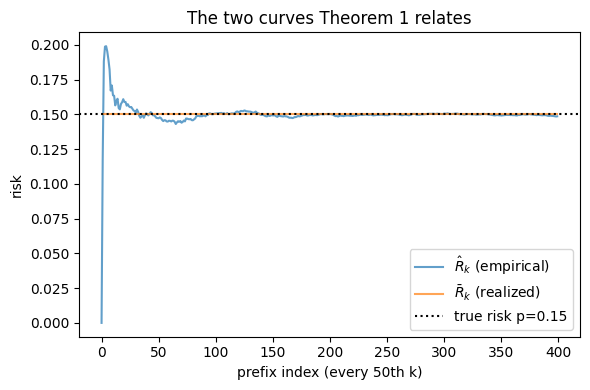

In [3]:
curves = sorted_filtration.realized_and_empirical_curves(losses, pi, eta=eta)

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(curves.Rhat_k[::50], label=r"$\hat R_k$ (empirical)", alpha=0.7)
ax.plot(curves.Rbar_k[::50], label=r"$\bar R_k$ (realized)", alpha=0.7)
ax.axhline(p, color="black", linestyle=":", label=f"true risk p={p}")
ax.set_xlabel("prefix index (every 50th k)")
ax.set_ylabel("risk")
ax.legend()
ax.set_title("The two curves Theorem 1 relates")
plt.tight_layout()
plt.show()

Both curves fluctuate around the true risk $p=0.15$, exactly as expected in a homogeneous
world with an uninformative score -- there's no reason the top-$k$ items by an
uninformative score should have any different risk than the population average.

## Step 2: the $\lambda_j$-menu and the band itself

Theorem 1 builds $U_k$ as a minimum over a menu of candidate bounds, each tuned to be
tightest around a different scale of $k$.

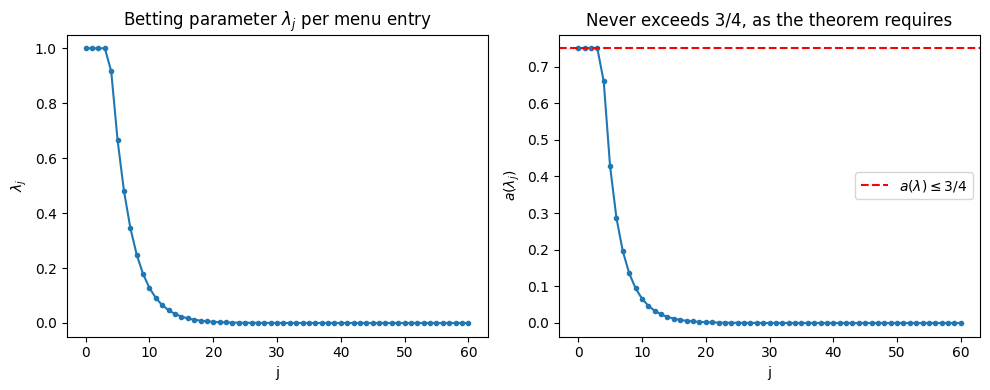

In [4]:
delta = 0.05
menu = uniform_band.lambda_menu(delta, j_max=60)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].plot(menu["lambda_j"], marker=".")
axes[0].set_xlabel("j")
axes[0].set_ylabel(r"$\lambda_j$")
axes[0].set_title(r"Betting parameter $\lambda_j$ per menu entry")

axes[1].plot(menu["a_lambda_j"], marker=".")
axes[1].axhline(0.75, color="red", linestyle="--", label=r"$a(\lambda) \leq 3/4$")
axes[1].set_xlabel("j")
axes[1].set_ylabel(r"$a(\lambda_j)$")
axes[1].legend()
axes[1].set_title("Never exceeds 3/4, as the theorem requires")
plt.tight_layout()
plt.show()

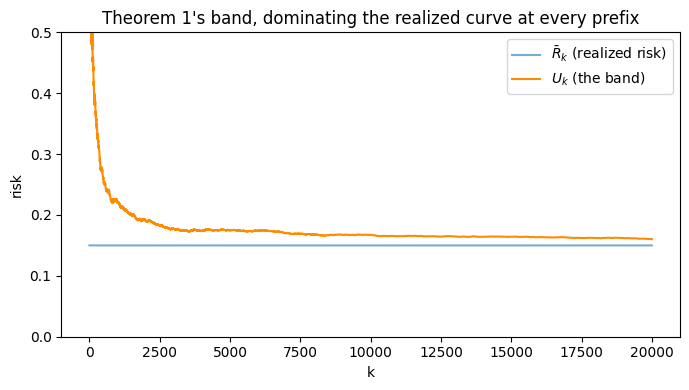

Confirmed: U_k >= Rbar_k at all 20000 prefixes.


In [5]:
U_k = uniform_band._band_from_curve(curves.Rhat_k, delta=delta)

fig, ax = plt.subplots(figsize=(7, 4))
k_axis = np.arange(1, n + 1)
ax.plot(k_axis, curves.Rbar_k, label=r"$\bar R_k$ (realized risk)", alpha=0.6)
ax.plot(k_axis, U_k, label=r"$U_k$ (the band)", color="darkorange")
ax.set_xlabel("k")
ax.set_ylabel("risk")
ax.set_ylim(0, 0.5)
ax.legend()
ax.set_title("Theorem 1's band, dominating the realized curve at every prefix")
plt.tight_layout()
plt.show()

assert np.all(U_k >= curves.Rbar_k), "the band must dominate at every single k -- this is the whole theorem"
print("Confirmed: U_k >= Rbar_k at all", n, "prefixes.")

## Step 3: does it actually hold up under repetition?

One replication proves nothing on its own. Let's run the same construction 200 times (a
smaller version of the paper's own 1,000-replication Table 3 check) and confirm the band is
never violated.

In [6]:
from src.utils.determinism import derive_seed

n_reps = 200
violations = 0
for rep in range(n_reps):
    rep_rng = np.random.default_rng(derive_seed("notebook01/homogeneous", rep))
    rep_losses = rep_rng.binomial(1, p, size=n).astype(float)
    rep_scores = rep_rng.normal(size=n)
    result = uniform_band.compute(rep_losses, rep_scores, delta=delta, k_min=100, rng=rep_rng, eta=eta)
    if is_violated(result.Rbar_k, result.U_k, k_min=100).violated:
        violations += 1

lo, hi = clopper_pearson_ci_on_rate(violations, n_reps)
print(f"Violations: {violations}/{n_reps}")
print(f"95% CI on the violation rate: [{lo:.4f}, {hi:.4f}]")
print(f"(the paper's own full-scale check, 1,000 reps, reports 0.0000, [0.0000, 0.0037] -- Table 3)")

Violations: 0/200
95% CI on the violation rate: [0.0000, 0.0183]
(the paper's own full-scale check, 1,000 reps, reports 0.0000, [0.0000, 0.0037] -- Table 3)


## Where to go next

- `02_baselines_comparison.ipynb` -- how much wider is this band than a fixed-$k$
  certificate, and why does that width buy post-hoc validity?
- `03_wsr_bug_deepdive.ipynb` -- the betting-bound defect this paper's audit found, and
  the one-line patch that fixes it.
- `04_block_robustness_demo.ipynb` -- Theorem 4, and what happens when items aren't
  actually independent.
- `src/bands/uniform_band.py` -- the full implementation, with every line traceable back
  to a specific equation in the paper (see `docs/ARCHITECTURE.md`).